# 🏥 Indian Liver Patient Disease Prediction
### End-to-End Machine Learning Project

**Dataset:** Indian Liver Patient Dataset (ILPD)  
**Goal:** Predict whether a patient has liver disease (1) or not (0)  
**Models Used:** Logistic Regression, Decision Tree, Random Forest, SVM, XGBoost, LightGBM  
**Dataset Types:** Age-Based, Gender-Based, Hybrid  


## 🟢 STEP 1: Import Libraries
We import all the necessary libraries for data processing, visualization, and machine learning.

In [4]:
# ── Data Handling ──
import numpy as np
import pandas as pd

# ── Visualization ──
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Preprocessing ──
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ── Class Imbalance ──
from imblearn.over_sampling import SMOTE

# ── Machine Learning Models ──
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── Evaluation Metrics ──
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

# ── Utilities ──
import warnings
warnings.filterwarnings('ignore')

# Set a consistent random seed for reproducibility
SEED = 42
np.random.seed(SEED)

print('✅ All libraries imported successfully!')


✅ All libraries imported successfully!


## 🟢 STEP 2: Load Dataset
We load the CSV file and take a first look at the data.

In [5]:
# Load the dataset
df = pd.read_csv('data/indian_liver_patient.csv')

print('Shape of dataset:', df.shape)
print('\nFirst 5 rows:')
df.head()


Shape of dataset: (583, 11)

First 5 rows:


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [6]:
# Dataset basic information: column types, non-null counts
print('Dataset Info:')
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [7]:
# Check for missing values
print('Missing values in each column:')
print(df.isnull().sum())


Missing values in each column:
Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64


## 🟢 STEP 3: Data Preprocessing
We will clean and prepare the data step-by-step before feeding it into any model.

### 3.1 Handle Missing Values
The `Albumin_and_Globulin_Ratio` column has 4 missing values. We fill them with the column median.

In [8]:
# Fill missing values in 'Albumin_and_Globulin_Ratio' with median
df['Albumin_and_Globulin_Ratio'].fillna(df['Albumin_and_Globulin_Ratio'].median(), inplace=True)

print('Missing values after imputation:')
print(df.isnull().sum())


Missing values after imputation:
Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64


### 3.2 Encode Categorical Variable (Gender)
Machine learning models only understand numbers. We convert `Male → 1` and `Female → 0`.

In [9]:
# Label Encode: Male=1, Female=0
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

print('Gender encoding (Male=1, Female=0):')
print(df['Gender'].value_counts())


Gender encoding (Male=1, Female=0):
Gender
1    441
0    142
Name: count, dtype: int64


### 3.3 Convert Target Variable
Original: `1 = liver disease`, `2 = no disease`  
We remap to: `1 = disease`, `0 = no disease` (standard binary classification).

In [10]:
# Convert: 1 stays 1 (disease), 2 becomes 0 (no disease)
df['Dataset'] = df['Dataset'].map({1: 1, 2: 0})

print('Target class distribution after remapping:')
print(df['Dataset'].value_counts())
print('\n1 = Liver Disease | 0 = No Disease')


Target class distribution after remapping:
Dataset
1    416
0    167
Name: count, dtype: int64

1 = Liver Disease | 0 = No Disease


### 3.4 Feature Scaling with StandardScaler
Scales all features to have mean=0 and std=1. This is important for models like SVM and Logistic Regression.

In [11]:
# Separate features (X) and target (y)
X = df.drop('Dataset', axis=1)
y = df['Dataset']

# Apply Standard Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('Feature scaling done. Sample of scaled features:')
X_scaled.head(3)


Feature scaling done. Sample of scaled features:


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio
0,1.252098,-1.762281,-0.418878,-0.493964,-0.426715,-0.354665,-0.318393,0.292120,0.198969,-0.147529
1,1.066637,0.567446,1.225171,1.430423,1.682629,-0.091599,-0.034333,0.937566,0.073157,-0.650323
2,1.066637,0.567446,0.644919,0.931508,0.821588,-0.113522,-0.145186,0.476533,0.198969,-0.178953


### 3.5 Handle Class Imbalance with SMOTE
SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic samples for the minority class so the model does not get biased towards the majority class.

In [12]:
# Apply SMOTE to balance classes
smote = SMOTE(random_state=SEED)
X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

print('Class distribution BEFORE SMOTE:', dict(y.value_counts()))
print('Class distribution AFTER  SMOTE:', dict(pd.Series(y_balanced).value_counts()))


Class distribution BEFORE SMOTE: {1: np.int64(416), 0: np.int64(167)}
Class distribution AFTER  SMOTE: {1: np.int64(416), 0: np.int64(416)}


## 🟢 STEP 4: Exploratory Data Analysis (EDA)
We explore the data visually to find patterns, distributions, and correlations.

In [13]:
# Summary statistics for all columns
print('Summary Statistics:')
df.describe().round(2)


Summary Statistics:


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.00,583.00,583.00,583.00,583.00,583.00,583.00,583.00,583.00,583.00,583.00
mean,44.75,0.76,3.30,1.49,290.58,80.71,109.91,6.48,3.14,0.95,0.71
std,16.19,0.43,6.21,2.81,242.94,182.62,288.92,1.09,0.80,0.32,0.45
min,4.00,0.00,0.40,0.10,63.00,10.00,10.00,2.70,0.90,0.30,0.00
25%,33.00,1.00,0.80,0.20,175.50,23.00,25.00,5.80,2.60,0.70,0.00
50%,45.00,1.00,1.00,0.30,208.00,35.00,42.00,6.60,3.10,0.93,1.00
75%,58.00,1.00,2.60,1.30,298.00,60.50,87.00,7.20,3.80,1.10,1.00
max,90.00,1.00,75.00,19.70,2110.00,2000.00,4929.00,9.60,5.50,2.80,1.00


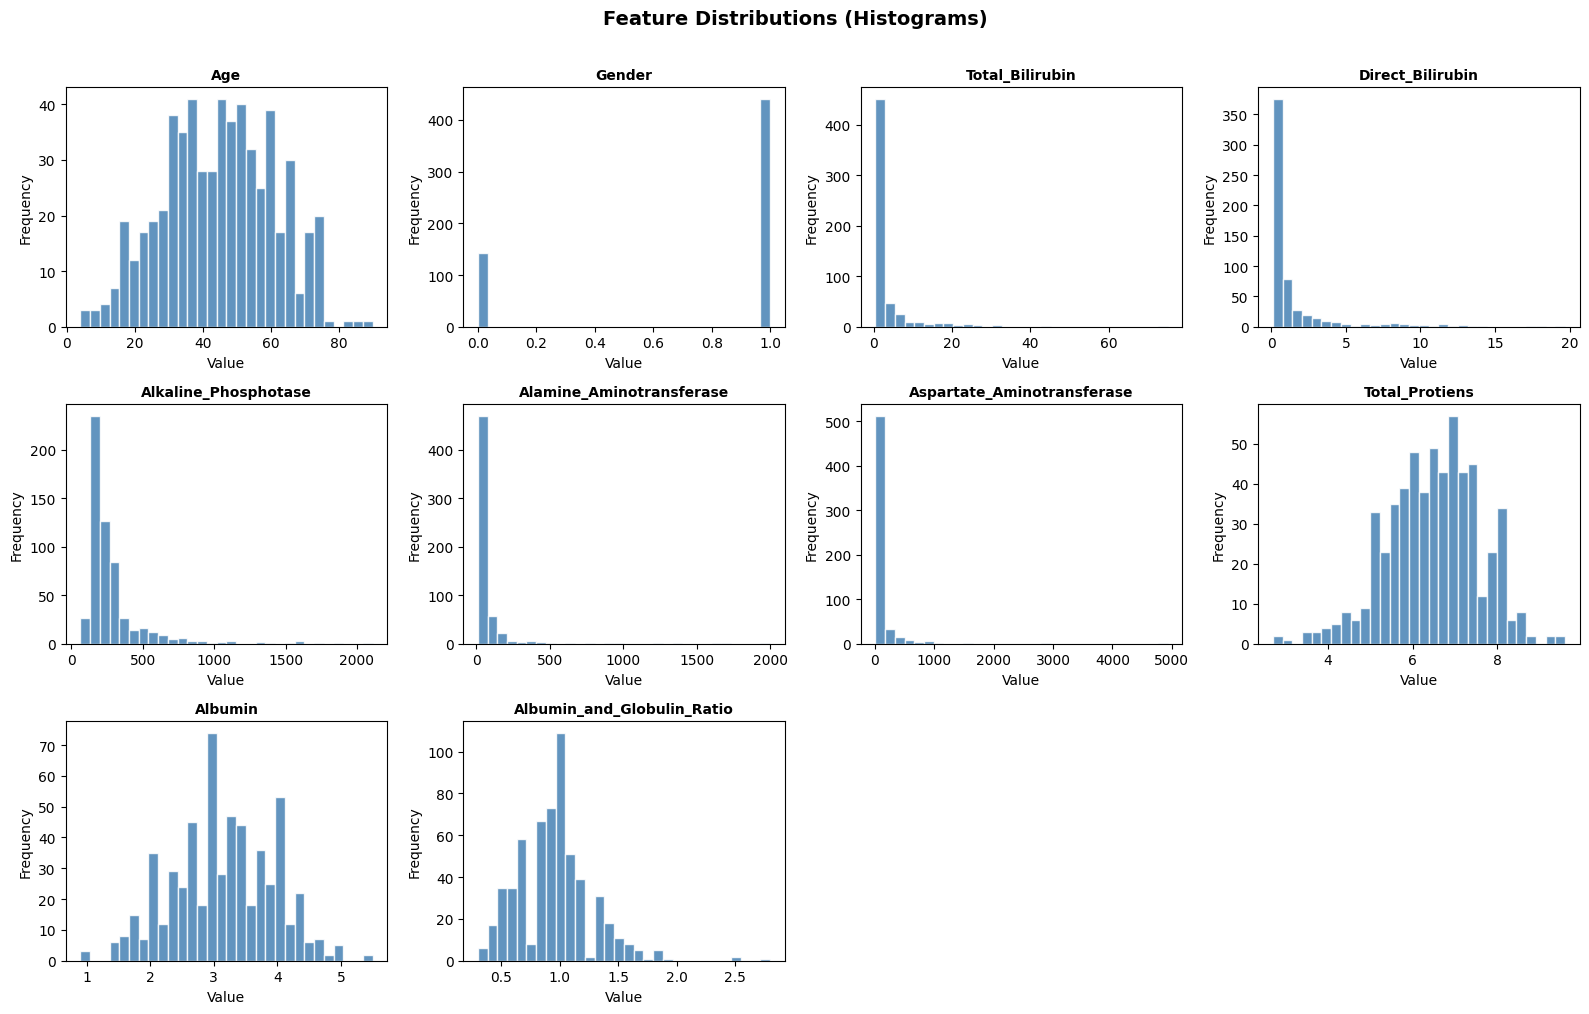

📌 Insight: Bilirubin and enzyme values (ALT, AST) are highly right-skewed, suggesting extreme values in sick patients.


In [14]:
# ── Histograms for all numeric features ──
numeric_cols = df.select_dtypes(include=np.number).columns.drop('Dataset')

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide any unused subplot panels
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions (Histograms)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_histograms.png', dpi=100, bbox_inches='tight')
plt.show()
print('📌 Insight: Bilirubin and enzyme values (ALT, AST) are highly right-skewed, suggesting extreme values in sick patients.')


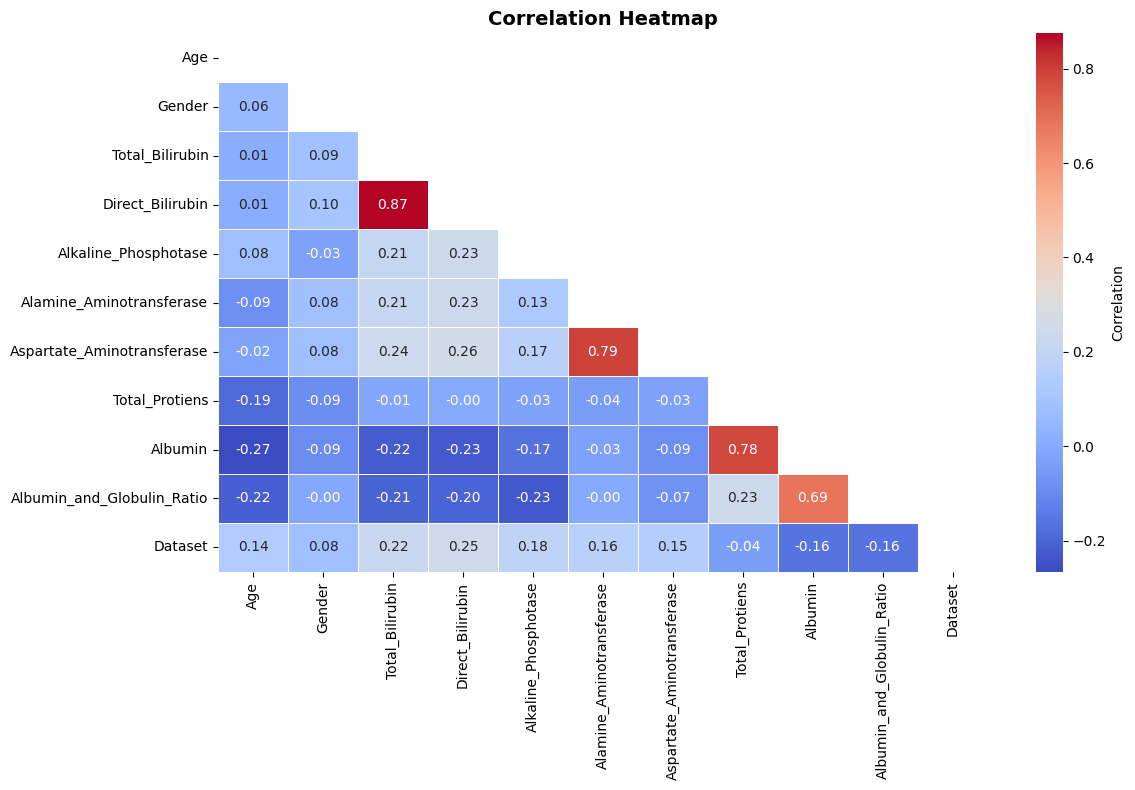

📌 Insight: Total_Bilirubin & Direct_Bilirubin are highly correlated (expected). Alamine & Aspartate aminotransferases also correlate strongly.


In [15]:
# ── Correlation Heatmap ──
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print('📌 Insight: Total_Bilirubin & Direct_Bilirubin are highly correlated (expected). Alamine & Aspartate aminotransferases also correlate strongly.')


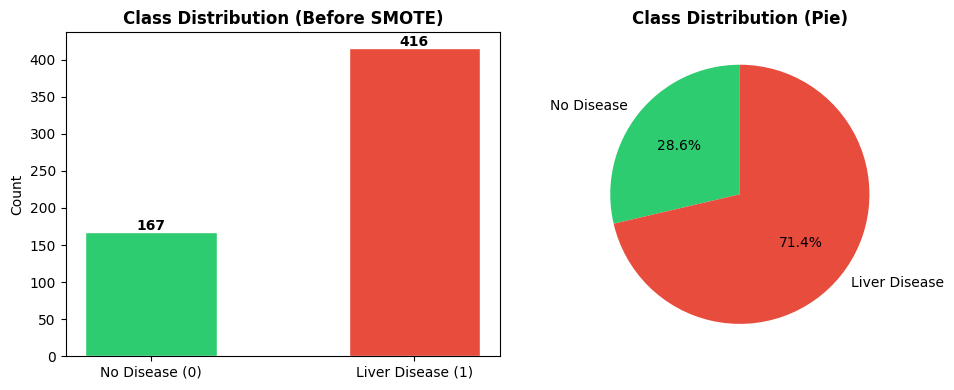

📌 Insight: Dataset is imbalanced (~71% disease vs ~29% no disease). SMOTE fixes this.


In [16]:
# ── Class Distribution Plot ──
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
counts = df['Dataset'].value_counts()
axes[0].bar(['No Disease (0)', 'Liver Disease (1)'], [counts[0], counts[1]],
            color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution (Before SMOTE)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie([counts[0], counts[1]], labels=['No Disease', 'Liver Disease'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (Pie)', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_class_dist.png', dpi=100, bbox_inches='tight')
plt.show()
print('📌 Insight: Dataset is imbalanced (~71% disease vs ~29% no disease). SMOTE fixes this.')


## 🟢 STEP 5: Create 3 Types of Datasets
We split the data in three different ways to study how patient demographics affect model performance.

### 5A: Age-Based Dataset
We group patients into: `Young (<30)`, `Middle (30–50)`, `Senior (>50)`

In [17]:
# Create age groups
df_age = df.copy()
df_age['AgeGroup'] = pd.cut(df_age['Age'],
                             bins=[0, 30, 50, 200],
                             labels=['Young', 'Middle', 'Senior'])

# Split into 3 sub-datasets
df_young  = df_age[df_age['AgeGroup'] == 'Young'].drop('AgeGroup', axis=1)
df_middle = df_age[df_age['AgeGroup'] == 'Middle'].drop('AgeGroup', axis=1)
df_senior = df_age[df_age['AgeGroup'] == 'Senior'].drop('AgeGroup', axis=1)

print('Age Group Sizes:')
print(f'  Young  (<30): {len(df_young)} patients')
print(f'  Middle (30-50): {len(df_middle)} patients')
print(f'  Senior (>50): {len(df_senior)} patients')


Age Group Sizes:
  Young  (<30): 115 patients
  Middle (30-50): 261 patients
  Senior (>50): 207 patients


### 5B: Gender-Based Dataset

In [18]:
# Split by Gender (1=Male, 0=Female after encoding)
df_male   = df[df['Gender'] == 1].copy()
df_female = df[df['Gender'] == 0].copy()

print('Gender Group Sizes:')
print(f'  Male:   {len(df_male)} patients')
print(f'  Female: {len(df_female)} patients')


Gender Group Sizes:
  Male:   441 patients
  Female: 142 patients


### 5C: Hybrid Dataset (Age + Gender)

In [19]:
# Combine Age + Gender into one group label
df_hybrid = df_age.copy()
df_hybrid['GenderLabel'] = df_hybrid['Gender'].map({1: 'Male', 0: 'Female'})
df_hybrid['HybridGroup'] = df_hybrid['AgeGroup'].astype(str) + '_' + df_hybrid['GenderLabel']

print('Hybrid Groups and Patient Counts:')
print(df_hybrid['HybridGroup'].value_counts().to_string())


Hybrid Groups and Patient Counts:
HybridGroup
Middle_Male      192
Senior_Male      168
Young_Male        81
Middle_Female     69
Senior_Female     39
Young_Female      34


## 🟢 STEP 6: Model Training
We define a reusable helper function to train all 6 models on any dataset.

In [20]:
def prepare_data(subset_df):
    """
    Prepares a subset dataframe:
    - Drops non-numeric group columns if present
    - Scales features
    - Applies SMOTE
    - Splits into train/test
    Returns: X_train, X_test, y_train, y_test
    """
    # Drop any group label columns (used in hybrid/age splits)
    drop_cols = [c for c in ['AgeGroup', 'GenderLabel', 'HybridGroup'] if c in subset_df.columns]
    data = subset_df.drop(columns=drop_cols)

    X = data.drop('Dataset', axis=1)
    y = data['Dataset']

    # If only one class present, skip SMOTE (not enough data)
    if y.nunique() < 2 or len(y) < 20:
        return None

    # Scale
    sc = StandardScaler()
    X_sc = sc.fit_transform(X)

    # SMOTE — only apply if minority class has at least 6 samples
    minority = y.value_counts().min()
    if minority >= 6:
        sm = SMOTE(random_state=SEED, k_neighbors=min(5, minority-1))
        X_sc, y = sm.fit_resample(X_sc, y)

    return train_test_split(X_sc, y, test_size=0.2, random_state=SEED, stratify=y)


def get_models():
    """Returns a dictionary of all 6 models."""
    return {
        'Logistic Regression': LogisticRegression(random_state=SEED, max_iter=1000),
        'Decision Tree':       DecisionTreeClassifier(random_state=SEED),
        'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=SEED),
        'SVM':                 SVC(probability=True, random_state=SEED),
        'XGBoost':             XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0),
        'LightGBM':            LGBMClassifier(random_state=SEED, verbose=-1),
    }


def evaluate_model(model, X_train, X_test, y_train, y_test):
    """Trains model and returns all evaluation metrics as a dictionary."""
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
    }


def run_all_models(subset_df, label=''):
    """
    Trains all 6 models on a dataset subset.
    Returns a DataFrame of results.
    """
    split = prepare_data(subset_df)
    if split is None:
        print(f'  ⚠️  Skipping {label}: insufficient data')
        return None

    X_train, X_test, y_train, y_test = split
    results = []

    for name, model in get_models().items():
        metrics = evaluate_model(model, X_train, X_test, y_train, y_test)
        metrics['Model'] = name
        metrics['Group'] = label
        results.append(metrics)

    df_res = pd.DataFrame(results)[['Group', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
    return df_res


print('✅ Helper functions defined!')


✅ Helper functions defined!


### Model 1: Logistic Regression
A simple linear classifier. Works by finding a decision boundary using log-odds. Best for linearly separable data.

In [21]:
# Train Logistic Regression on the full balanced dataset
lr_model = LogisticRegression(random_state=SEED, max_iter=1000)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=SEED, stratify=y_balanced
)
lr_model.fit(X_train, y_train)
lr_metrics = evaluate_model(lr_model, X_train, X_test, y_train, y_test)
print('Logistic Regression (Full Dataset):')
print(pd.DataFrame([lr_metrics]).to_string(index=False))


Logistic Regression (Full Dataset):
 Accuracy  Precision  Recall  F1-Score  ROC-AUC
   0.7605     0.8644  0.6145    0.7183   0.8361


### Model 2: Decision Tree
Builds a tree of if-else rules. Easy to interpret and visualize. Can overfit if not tuned.

In [22]:
dt_model = DecisionTreeClassifier(random_state=SEED)
dt_model.fit(X_train, y_train)
dt_metrics = evaluate_model(dt_model, X_train, X_test, y_train, y_test)
print('Decision Tree (Full Dataset):')
print(pd.DataFrame([dt_metrics]).to_string(index=False))


Decision Tree (Full Dataset):
 Accuracy  Precision  Recall  F1-Score  ROC-AUC
   0.7006     0.6813   0.747    0.7126   0.7009


### Model 3: Random Forest
An ensemble of decision trees. Reduces overfitting via majority voting. Very robust and powerful.

In [23]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_model.fit(X_train, y_train)
rf_metrics = evaluate_model(rf_model, X_train, X_test, y_train, y_test)
print('Random Forest (Full Dataset):')
print(pd.DataFrame([rf_metrics]).to_string(index=False))


Random Forest (Full Dataset):
 Accuracy  Precision  Recall  F1-Score  ROC-AUC
   0.7904     0.8158   0.747    0.7799   0.9108


### Model 4: SVM (Support Vector Machine)
Finds the hyperplane that best separates classes with maximum margin. Works well on small-medium datasets.

In [24]:
svm_model = SVC(probability=True, random_state=SEED)
svm_model.fit(X_train, y_train)
svm_metrics = evaluate_model(svm_model, X_train, X_test, y_train, y_test)
print('SVM (Full Dataset):')
print(pd.DataFrame([svm_metrics]).to_string(index=False))


SVM (Full Dataset):
 Accuracy  Precision  Recall  F1-Score  ROC-AUC
   0.7246     0.8776  0.5181    0.6515   0.8345


### Model 5: XGBoost
Gradient boosting using decision trees. Trains trees sequentially, each correcting errors of the previous. State-of-the-art for tabular data.

In [25]:
xgb_model = XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0)
xgb_model.fit(X_train, y_train)
xgb_metrics = evaluate_model(xgb_model, X_train, X_test, y_train, y_test)
print('XGBoost (Full Dataset):')
print(pd.DataFrame([xgb_metrics]).to_string(index=False))


XGBoost (Full Dataset):
 Accuracy  Precision  Recall  F1-Score  ROC-AUC
   0.8443     0.8353  0.8554    0.8452   0.9234


### Model 6: LightGBM
Like XGBoost but faster and more memory-efficient. Uses leaf-wise tree growth strategy.

In [26]:
lgbm_model = LGBMClassifier(random_state=SEED, verbose=-1)
lgbm_model.fit(X_train, y_train)
lgbm_metrics = evaluate_model(lgbm_model, X_train, X_test, y_train, y_test)
print('LightGBM (Full Dataset):')
print(pd.DataFrame([lgbm_metrics]).to_string(index=False))


LightGBM (Full Dataset):
 Accuracy  Precision  Recall  F1-Score  ROC-AUC
   0.7964     0.8182   0.759    0.7875   0.9076


## 🟢 STEP 7: Model Evaluation with Confusion Matrices
We evaluate each model with all metrics and show the confusion matrix heatmap.

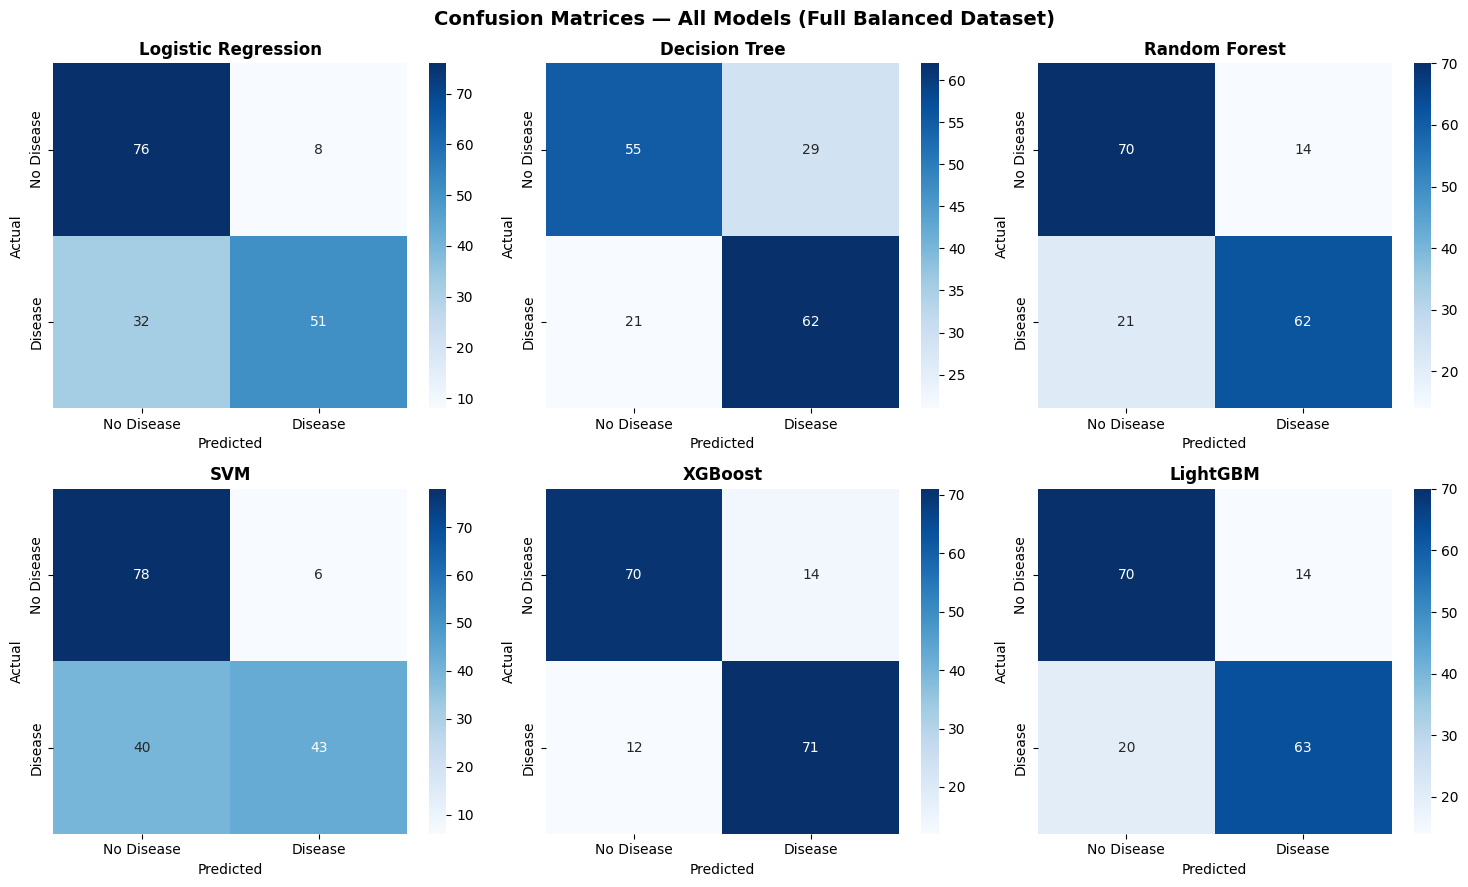


📊 Full Dataset — All Model Metrics:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7605,0.8644,0.6145,0.7183,0.8361
1,Decision Tree,0.7006,0.6813,0.7470,0.7126,0.7009
2,Random Forest,0.7904,0.8158,0.7470,0.7799,0.9108
3,SVM,0.7246,0.8776,0.5181,0.6515,0.8345
4,XGBoost,0.8443,0.8353,0.8554,0.8452,0.9234
5,LightGBM,0.7964,0.8182,0.7590,0.7875,0.9076


In [27]:
# Collect all model metrics on the full balanced dataset
all_model_results = []
trained_models = {}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (name, model) in enumerate(get_models().items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = evaluate_model(model, X_train, X_test, y_train, y_test)
    metrics['Model'] = name
    all_model_results.append(metrics)
    trained_models[name] = model

    # Confusion Matrix plot
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    axes[idx].set_title(f'{name}', fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models (Full Balanced Dataset)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

# Show metrics table
results_df = pd.DataFrame(all_model_results)[['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC']]
print('\n📊 Full Dataset — All Model Metrics:')
results_df


## 🟢 STEP 8: Evaluation Per Category
Now we train and evaluate all 6 models on each sub-dataset.

### 8A: Age-Based Evaluation

In [28]:
age_results = []

for group_name, subset in [('Young', df_young), ('Middle', df_middle), ('Senior', df_senior)]:
    print(f'Training on Age Group: {group_name}...')
    res = run_all_models(subset, label=group_name)
    if res is not None:
        age_results.append(res)

age_results_df = pd.concat(age_results, ignore_index=True)

print('\n📊 Age-Based Evaluation Table:')
age_results_df


Training on Age Group: Young...
Training on Age Group: Middle...
Training on Age Group: Senior...

📊 Age-Based Evaluation Table:


,Group,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Young,Logistic Regression,0.6538,0.6667,0.6154,0.6400,0.6331
1,Young,Decision Tree,0.6923,0.6316,0.9231,0.7500,0.6923
2,Young,Random Forest,0.6154,0.6000,0.6923,0.6429,0.6598
3,Young,SVM,0.5769,0.6000,0.4615,0.5217,0.5799
4,Young,XGBoost,0.5769,0.5625,0.6923,0.6207,0.6509
5,Young,LightGBM,0.5769,0.5625,0.6923,0.6207,0.6509
6,Middle,Logistic Regression,0.7051,0.8636,0.4872,0.6230,0.7087
7,Middle,Decision Tree,0.7949,0.8108,0.7692,0.7895,0.7949
8,Middle,Random Forest,0.7949,0.9259,0.6410,0.7576,0.9037
9,Middle,SVM,0.7051,0.8333,0.5128,0.6349,0.8337


### 8B: Gender-Based Evaluation

In [29]:
gender_results = []

for group_name, subset in [('Male', df_male), ('Female', df_female)]:
    print(f'Training on Gender Group: {group_name}...')
    res = run_all_models(subset, label=group_name)
    if res is not None:
        gender_results.append(res)

gender_results_df = pd.concat(gender_results, ignore_index=True)

print('\n📊 Gender-Based Evaluation Table:')
gender_results_df


Training on Gender Group: Male...
Training on Gender Group: Female...

📊 Gender-Based Evaluation Table:


,Group,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Male,Logistic Regression,0.7231,0.8085,0.5846,0.6786,0.7837
1,Male,Decision Tree,0.7923,0.7969,0.7846,0.7907,0.7923
2,Male,Random Forest,0.8231,0.8387,0.8000,0.8189,0.9108
3,Male,SVM,0.7154,0.8182,0.5538,0.6606,0.8213
4,Male,XGBoost,0.8308,0.8644,0.7846,0.8226,0.9155
5,Male,LightGBM,0.8308,0.8772,0.7692,0.8197,0.9084
6,Female,Logistic Regression,0.7297,0.7857,0.6111,0.6875,0.7251
7,Female,Decision Tree,0.7027,0.6667,0.7778,0.7179,0.7047
8,Female,Random Forest,0.6757,0.6875,0.6111,0.6471,0.7982
9,Female,SVM,0.6757,0.7143,0.5556,0.6250,0.7456


### 8C: Hybrid Evaluation (Age + Gender)

In [30]:
hybrid_results = []
hybrid_groups = df_hybrid.groupby('HybridGroup')

for group_name, subset in hybrid_groups:
    subset_clean = subset.drop(columns=['AgeGroup', 'GenderLabel', 'HybridGroup'])
    print(f'Training on Hybrid Group: {group_name} (n={len(subset_clean)})...')
    res = run_all_models(subset_clean, label=group_name)
    if res is not None:
        hybrid_results.append(res)

hybrid_results_df = pd.concat(hybrid_results, ignore_index=True)

print('\n📊 Hybrid Evaluation Table:')
hybrid_results_df


Training on Hybrid Group: Middle_Female (n=69)...
Training on Hybrid Group: Middle_Male (n=192)...
Training on Hybrid Group: Senior_Female (n=39)...
Training on Hybrid Group: Senior_Male (n=168)...
Training on Hybrid Group: Young_Female (n=34)...
Training on Hybrid Group: Young_Male (n=81)...

📊 Hybrid Evaluation Table:


,Group,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Middle_Female,Logistic Regression,0.8500,0.8889,0.8000,0.8421,0.8200
1,Middle_Female,Decision Tree,0.7000,0.6667,0.8000,0.7273,0.7000
2,Middle_Female,Random Forest,0.7500,0.6923,0.9000,0.7826,0.8300
3,Middle_Female,SVM,0.7500,0.7778,0.7000,0.7368,0.7300
4,Middle_Female,XGBoost,0.7500,0.6923,0.9000,0.7826,0.7600
5,Middle_Female,LightGBM,0.7500,0.7273,0.8000,0.7619,0.7200
6,Middle_Male,Logistic Regression,0.5932,0.6667,0.3448,0.4545,0.6782
7,Middle_Male,Decision Tree,0.6780,0.6667,0.6897,0.6780,0.6782
8,Middle_Male,Random Forest,0.8136,0.8750,0.7241,0.7925,0.9172
9,Middle_Male,SVM,0.6610,0.8462,0.3793,0.5238,0.8057


## 🟢 STEP 9: Final Overall Evaluation
We combine all results and identify the best model.

In [31]:
# Combine all results
full_dataset_res = results_df.copy()
full_dataset_res.insert(0, 'Group', 'Full Dataset')

combined_df = pd.concat([full_dataset_res, age_results_df, gender_results_df, hybrid_results_df], ignore_index=True)

print('Combined Results Shape:', combined_df.shape)
combined_df.head(10)


Combined Results Shape: (72, 7)


,Group,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Full Dataset,Logistic Regression,0.7605,0.8644,0.6145,0.7183,0.8361
1,Full Dataset,Decision Tree,0.7006,0.6813,0.7470,0.7126,0.7009
2,Full Dataset,Random Forest,0.7904,0.8158,0.7470,0.7799,0.9108
3,Full Dataset,SVM,0.7246,0.8776,0.5181,0.6515,0.8345
4,Full Dataset,XGBoost,0.8443,0.8353,0.8554,0.8452,0.9234
5,Full Dataset,LightGBM,0.7964,0.8182,0.7590,0.7875,0.9076
6,Young,Logistic Regression,0.6538,0.6667,0.6154,0.6400,0.6331
7,Young,Decision Tree,0.6923,0.6316,0.9231,0.7500,0.6923
8,Young,Random Forest,0.6154,0.6000,0.6923,0.6429,0.6598
9,Young,SVM,0.5769,0.6000,0.4615,0.5217,0.5799


In [32]:
# ── Best model OVERALL (by ROC-AUC on full dataset) ──
best_overall = full_dataset_res.sort_values('ROC-AUC', ascending=False).iloc[0]
print('🏆 Best Model Overall (by ROC-AUC):')
print(f"   Model: {best_overall['Model']}")
print(f"   ROC-AUC: {best_overall['ROC-AUC']}")
print(f"   Accuracy: {best_overall['Accuracy']}")

print()

# ── Best model by Recall (most important for medical diagnosis) ──
best_recall = full_dataset_res.sort_values('Recall', ascending=False).iloc[0]
print('🩺 Best Model for Recall (Medical Importance):')
print(f"   Model: {best_recall['Model']}")
print(f"   Recall: {best_recall['Recall']}")
print('   ℹ️  High recall means fewer missed disease cases (false negatives).')

print()

# ── Best model per dataset type ──
print('🔹 Best Model per Dataset Type (by Accuracy):')
for group_df, dtype in [(age_results_df, 'Age-Based'), (gender_results_df, 'Gender-Based'), (hybrid_results_df, 'Hybrid')]:
    best = group_df.sort_values('Accuracy', ascending=False).iloc[0]
    print(f"   {dtype}: {best['Model']} (Group={best['Group']}, Acc={best['Accuracy']})")


🏆 Best Model Overall (by ROC-AUC):
   Model: XGBoost
   ROC-AUC: 0.9234
   Accuracy: 0.8443

🩺 Best Model for Recall (Medical Importance):
   Model: XGBoost
   Recall: 0.8554
   ℹ️  High recall means fewer missed disease cases (false negatives).

🔹 Best Model per Dataset Type (by Accuracy):
   Age-Based: XGBoost (Group=Senior, Acc=0.8906)
   Gender-Based: LightGBM (Group=Male, Acc=0.8308)
   Hybrid: LightGBM (Group=Senior_Male, Acc=0.9259)


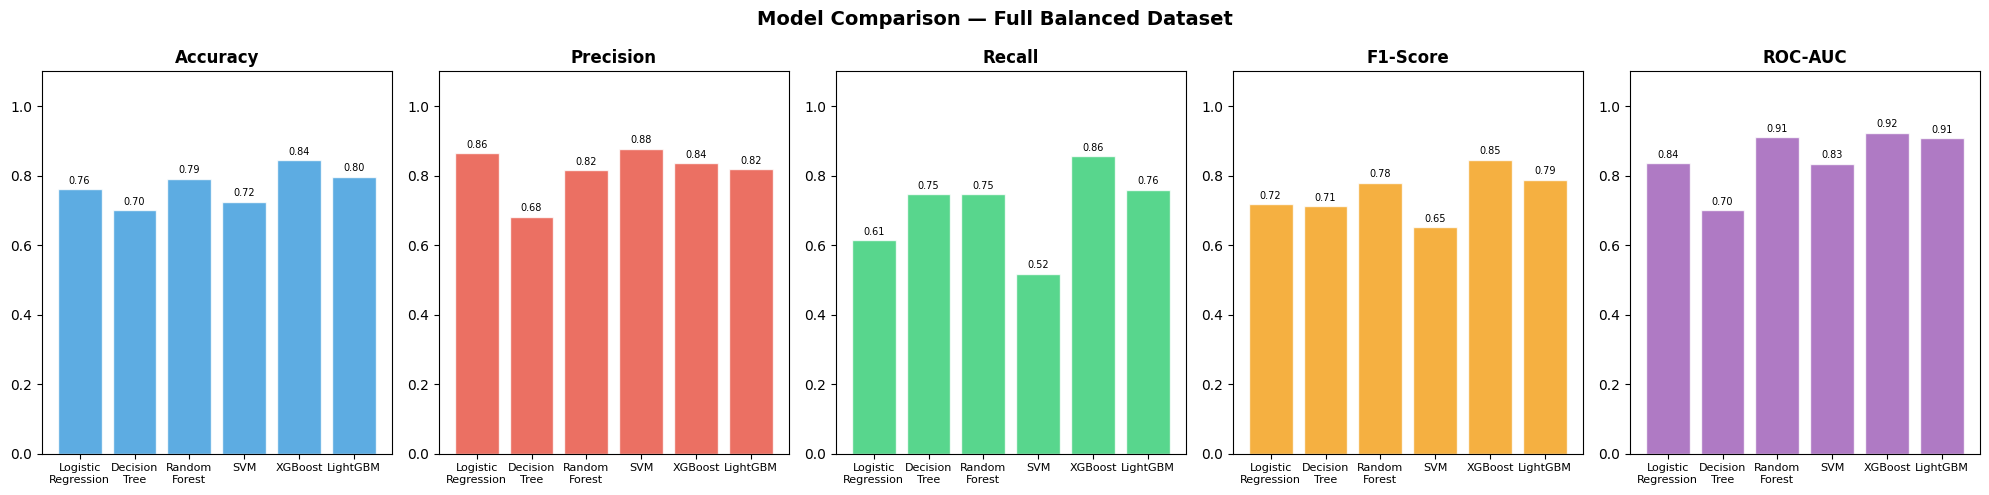

In [33]:
# ── Visual Comparison of All Models on Full Dataset ──
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(full_dataset_res))
model_names = full_dataset_res['Model'].tolist()

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    bars = axes[i].bar(x, full_dataset_res[metric], color=color, alpha=0.8, edgecolor='white')
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=8)
    axes[i].set_ylim(0, 1.1)
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}',
                     ha='center', va='bottom', fontsize=7)

plt.suptitle('Model Comparison — Full Balanced Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


## 🟢 STEP 10: Feature Importance
We use Random Forest and XGBoost to find which features are most important for predicting liver disease.

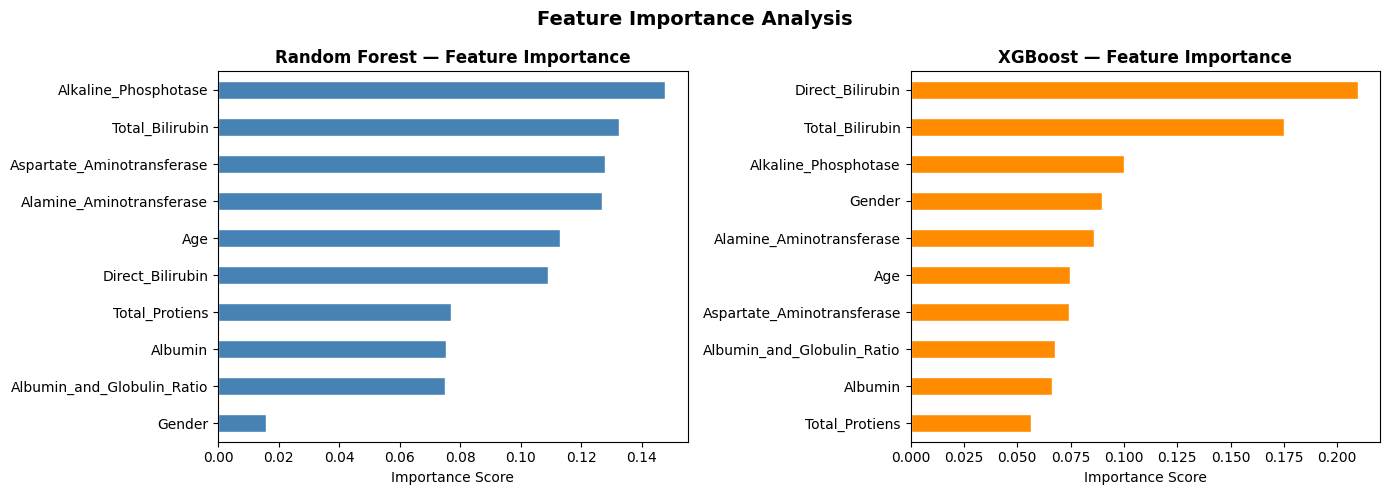


📌 Top 3 Most Important Features (Random Forest):
Alkaline_Phosphotase          0.147801
Total_Bilirubin               0.132492
Aspartate_Aminotransferase    0.128081

📌 Insight: Direct/Total Bilirubin and liver enzymes (ALT, AST) are the strongest predictors of liver disease.


In [34]:
feature_names = X.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Random Forest Feature Importance ──
rf_importance = pd.Series(trained_models['Random Forest'].feature_importances_, index=feature_names)
rf_importance.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Random Forest — Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# ── XGBoost Feature Importance ──
xgb_importance = pd.Series(trained_models['XGBoost'].feature_importances_, index=feature_names)
xgb_importance.sort_values().plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('XGBoost — Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n📌 Top 3 Most Important Features (Random Forest):')
print(rf_importance.sort_values(ascending=False).head(3).to_string())
print('\n📌 Insight: Direct/Total Bilirubin and liver enzymes (ALT, AST) are the strongest predictors of liver disease.')


## 🟢 STEP 11: Save the Best Model for Deployment
We save the best model and scaler so they can be loaded by the Streamlit app.

In [35]:
import pickle

# Identify and save best model (by ROC-AUC)
best_model_name = full_dataset_res.sort_values('ROC-AUC', ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]

# Re-fit scaler on original X (not SMOTE-balanced)
final_scaler = StandardScaler()
final_scaler.fit(X)

# Save model and scaler
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(final_scaler, f)

print(f'✅ Best model saved: {best_model_name}')
print('   Files saved: best_model.pkl, scaler.pkl')


✅ Best model saved: XGBoost
   Files saved: best_model.pkl, scaler.pkl
